# Notebook 08 — CSE-CIC-IDS2018 EDA

**Dataset:** CSE-CIC-IDS2018 (Kaggle: `solarmainframe/ids-intrusion-csv`)  
**Purpose:** Exploratory Data Analysis for the new dataset used in the FL-IDS project.  
**Note:** Loads from pre-built pipeline artifacts — runs in seconds, no re-processing needed.

### What this notebook shows
1. Dataset overview (row count, feature count, classes)
2. Class distribution with plot
3. Feature reduction funnel (raw → after each filter)
4. LabelEncoder class index mapping (used in config.yaml)
5. Class imbalance & weight caps
6. Feature correlation heatmap
7. Non-IID Dirichlet(α=0.5) client partition heatmap (50 clients)

In [1]:
import sys
sys.path.insert(0, '..')

import numpy as np
import pandas as pd
import pickle
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

from src.configs.paths import PREPROCESSED_DIR, DATA_DIR, ARTIFACTS_DIR

PLOTS_DIR = ARTIFACTS_DIR / 'plots'
PLOTS_DIR.mkdir(parents=True, exist_ok=True)

print('Imports OK')
print(f'Preprocessed dir: {PREPROCESSED_DIR}')

Imports OK
Preprocessed dir: C:\Users\rauna\Videos\FL IDS\artifacts\preprocessed


## Step 1 — Dataset Overview

In [2]:
# Load artifacts produced by data_pipeline.py
with open(PREPROCESSED_DIR / 'label_encoder.pkl', 'rb') as f:
    le = pickle.load(f)

with open(PREPROCESSED_DIR / 'feature_cols.pkl', 'rb') as f:
    feature_cols = pickle.load(f)

test_data = np.load(PREPROCESSED_DIR / 'test_set.npz')
X_test = test_data['X_test']
y_test = test_data['y_test']

# Load all client shards to reconstruct train set stats
num_clients = 50
X_parts, y_parts = [], []
for cid in range(num_clients):
    shard = np.load(DATA_DIR / f'client_{cid:04d}.npz')
    X_parts.append(shard['X_train'])
    y_parts.append(shard['y_train'])
X_train = np.concatenate(X_parts)
y_train = np.concatenate(y_parts)

total_rows = len(X_train) + len(X_test)
print('=' * 55)
print('  CSE-CIC-IDS2018 — Dataset Summary')
print('=' * 55)
print(f'  Total rows (train + test) : {total_rows:>12,}')
print(f'  Train rows                : {len(X_train):>12,}')
print(f'  Test rows                 : {len(X_test):>12,}')
print(f'  Features (input_dim)      : {len(feature_cols):>12}')
print(f'  Classes  (num_classes)    : {len(le.classes_):>12}')
print('=' * 55)

  CSE-CIC-IDS2018 — Dataset Summary
  Total rows (train + test) :   13,635,693
  Train rows                :   10,389,104
  Test rows                 :    3,246,589
  Features (input_dim)      :           44
  Classes  (num_classes)    :           15


## Step 2 — Class Distribution

In [3]:
y_all = np.concatenate([y_train, y_test])
class_names = le.classes_

counts = np.bincount(y_all, minlength=len(class_names))
pct    = counts / counts.sum() * 100

dist_df = pd.DataFrame({'Class': class_names, 'Count': counts, 'Pct (%)': pct.round(3)})
dist_df = dist_df.sort_values('Count', ascending=False).reset_index(drop=True)
print(dist_df.to_string(index=False))
print(f'\nImbalance ratio (max/min): {counts.max() / counts[counts > 0].min():,.0f}x')

                   Class    Count  Pct (%)
                  Benign 11327365   83.071
        DDOS attack-HOIC   576355    4.227
  DDoS attacks-LOIC-HTTP   483532    3.546
        DoS attacks-Hulk   388365    2.848
                     Bot   240393    1.763
          FTP-BruteForce   162545    1.192
          SSH-Bruteforce   157580    1.156
           Infilteration   136031    0.998
DoS attacks-SlowHTTPTest   117288    0.860
   DoS attacks-GoldenEye    34757    0.255
   DoS attacks-Slowloris     9278    0.068
    DDOS attack-LOIC-UDP     1417    0.010
        Brute Force -Web      516    0.004
        Brute Force -XSS      197    0.001
           SQL Injection       74    0.001

Imbalance ratio (max/min): 153,072x


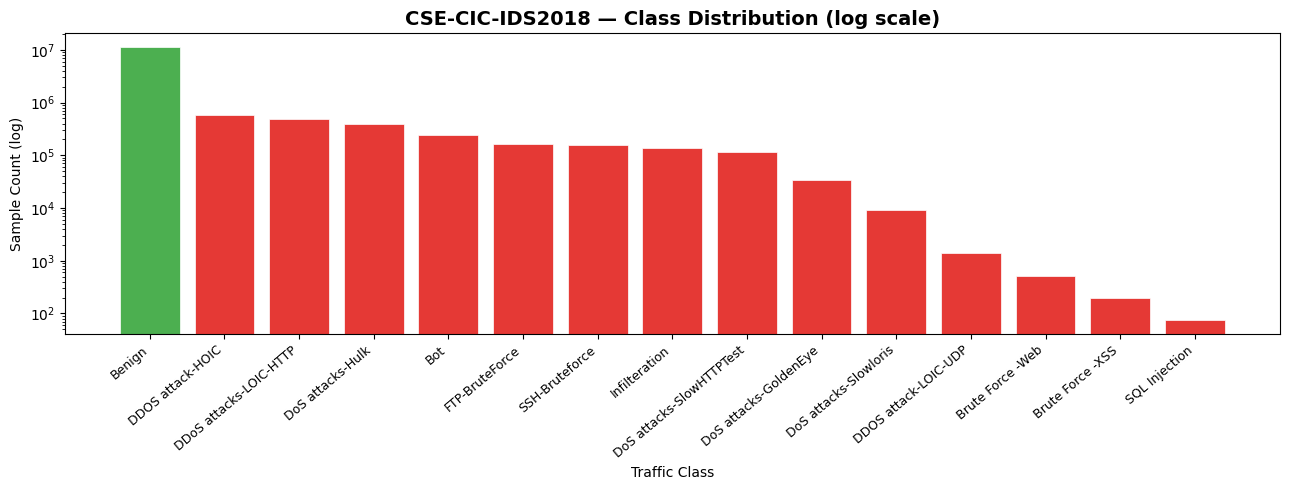

Saved: ids2018_class_dist.png


In [4]:
fig, ax = plt.subplots(figsize=(13, 5))
colors = ['#4CAF50' if n == 'Benign' else '#E53935' for n in dist_df['Class']]
ax.bar(dist_df['Class'], dist_df['Count'], color=colors, edgecolor='white', linewidth=0.5)
ax.set_yscale('log')
ax.set_title('CSE-CIC-IDS2018 — Class Distribution (log scale)', fontsize=14, fontweight='bold')
ax.set_ylabel('Sample Count (log)')
ax.set_xlabel('Traffic Class')
plt.xticks(rotation=40, ha='right', fontsize=9)
plt.tight_layout()
plt.savefig(PLOTS_DIR / 'ids2018_class_dist.png', dpi=150)
plt.show()
print('Saved: ids2018_class_dist.png')

## Step 3 — Feature Reduction Funnel

Feature reduction funnel:
  Raw (84 cols)                      : 84
  Drop metadata & non-numeric        : 79
  Variance filter                    : 79
  Correlation filter (r>0.95)        : 79
  Final features                     : 44


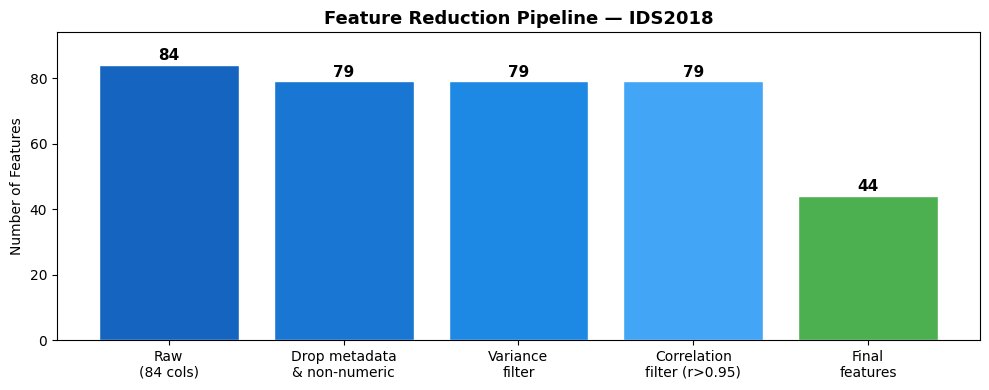

Saved: ids2018_feature_funnel.png


In [5]:
# Load the raw parquet to show what was dropped at each stage
raw_parquet = PREPROCESSED_DIR.parent / 'raw' / 'cicids2018_raw.parquet'

if raw_parquet.exists():
    df_raw = pd.read_parquet(raw_parquet)
    raw_cols = df_raw.shape[1]
else:
    raw_cols = 84  # known from load log
    print('Raw parquet not found, using known value from pipeline log.')

DROP_COLS    = ['Flow ID', 'Src IP', 'Dst IP', 'Timestamp']
after_drop   = raw_cols - len(DROP_COLS) - 1  # -1 for Label
after_var    = after_drop   # variance filter removed 0 in this dataset
after_corr   = len(feature_cols)

stages = ['Raw\n(84 cols)', 'Drop metadata\n& non-numeric', 'Variance\nfilter', 'Correlation\nfilter (r>0.95)', 'Final\nfeatures']
values = [raw_cols, after_drop, after_var, after_var, after_corr]

print('Feature reduction funnel:')
for s, v in zip(stages, values):
    print(f'  {s.replace(chr(10)," "):<35}: {v}')

fig, ax = plt.subplots(figsize=(10, 4))
bars = ax.bar(stages, values, color=['#1565C0','#1976D2','#1E88E5','#42A5F5','#4CAF50'], edgecolor='white')
for bar, val in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5, str(val),
            ha='center', va='bottom', fontweight='bold', fontsize=11)
ax.set_title('Feature Reduction Pipeline — IDS2018', fontsize=13, fontweight='bold')
ax.set_ylabel('Number of Features')
ax.set_ylim(0, raw_cols + 10)
plt.tight_layout()
plt.savefig(PLOTS_DIR / 'ids2018_feature_funnel.png', dpi=150)
plt.show()
print('Saved: ids2018_feature_funnel.png')

## Step 4 — LabelEncoder Class Index Mapping

In [6]:
print('LabelEncoder class → index mapping:')
print(f'{"Index":<8} {"Class Name":<35} {"Role"}')
print('-' * 65)
for idx, cls in enumerate(le.classes_):
    role = ''
    if 'benign' in cls.lower():              role = '<-- target_class (flip TO)'
    elif 'ddos attack-hoic' in cls.lower():  role = '<-- source_class (flip FROM)'
    print(f'{idx:<8} {cls:<35} {role}')

print()
print('Config values (already set in config.yaml):')
print(f'  input_dim    = {len(feature_cols)}')
print(f'  num_classes  = {len(le.classes_)}')
benign_idx = list(le.classes_).index('Benign')
hoic_idx   = list(le.classes_).index('DDOS attack-HOIC')
print(f'  source_class = {hoic_idx}  (DDOS attack-HOIC)')
print(f'  target_class = {benign_idx}  (Benign)')

LabelEncoder class → index mapping:
Index    Class Name                          Role
-----------------------------------------------------------------
0        Benign                              <-- target_class (flip TO)
1        Bot                                 
2        Brute Force -Web                    
3        Brute Force -XSS                    
4        DDOS attack-HOIC                    <-- source_class (flip FROM)
5        DDOS attack-LOIC-UDP                
6        DDoS attacks-LOIC-HTTP              
7        DoS attacks-GoldenEye               
8        DoS attacks-Hulk                    
9        DoS attacks-SlowHTTPTest            
10       DoS attacks-Slowloris               
11       FTP-BruteForce                      
12       Infilteration                       
13       SQL Injection                       
14       SSH-Bruteforce                      

Config values (already set in config.yaml):
  input_dim    = 44
  num_classes  = 15
  source_class = 4 

## Step 5 — Class Imbalance & Weight Cap

In [7]:
from sklearn.utils.class_weight import compute_class_weight

classes     = np.arange(len(le.classes_))
raw_weights = compute_class_weight('balanced', classes=classes, y=y_train)

print(f'{"Idx":<5} {"Class":<35} {"Raw Weight":>12} {"Capped@10":>10}')
print('-' * 65)
for i, (cls, w) in enumerate(zip(le.classes_, raw_weights)):
    capped = min(w, 10.0)
    flag = ' ***' if w > 10.0 else ''
    print(f'{i:<5} {cls:<35} {w:>12.2f} {capped:>10.2f}{flag}')

print(f'\nMax raw weight : {raw_weights.max():.2f}')
print(f'weight_cap=10.0 applied to {(raw_weights > 10).sum()} classes (*** above)')

Idx   Class                                 Raw Weight  Capped@10
-----------------------------------------------------------------
0     Benign                                      0.08       0.08
1     Bot                                         3.78       3.78
2     Brute Force -Web                         1757.89      10.00 ***
3     Brute Force -XSS                         4586.80      10.00 ***
4     DDOS attack-HOIC                            1.58       1.58
5     DDOS attack-LOIC-UDP                      646.69      10.00 ***
6     DDoS attacks-LOIC-HTTP                      1.88       1.88
7     DoS attacks-GoldenEye                      26.18      10.00 ***
8     DoS attacks-Hulk                            2.34       2.34
9     DoS attacks-SlowHTTPTest                    7.76       7.76
10    DoS attacks-Slowloris                      97.83      10.00 ***
11    FTP-BruteForce                              5.59       5.59
12    Infilteration                               6.68  

## Step 6 — Feature Correlation Heatmap

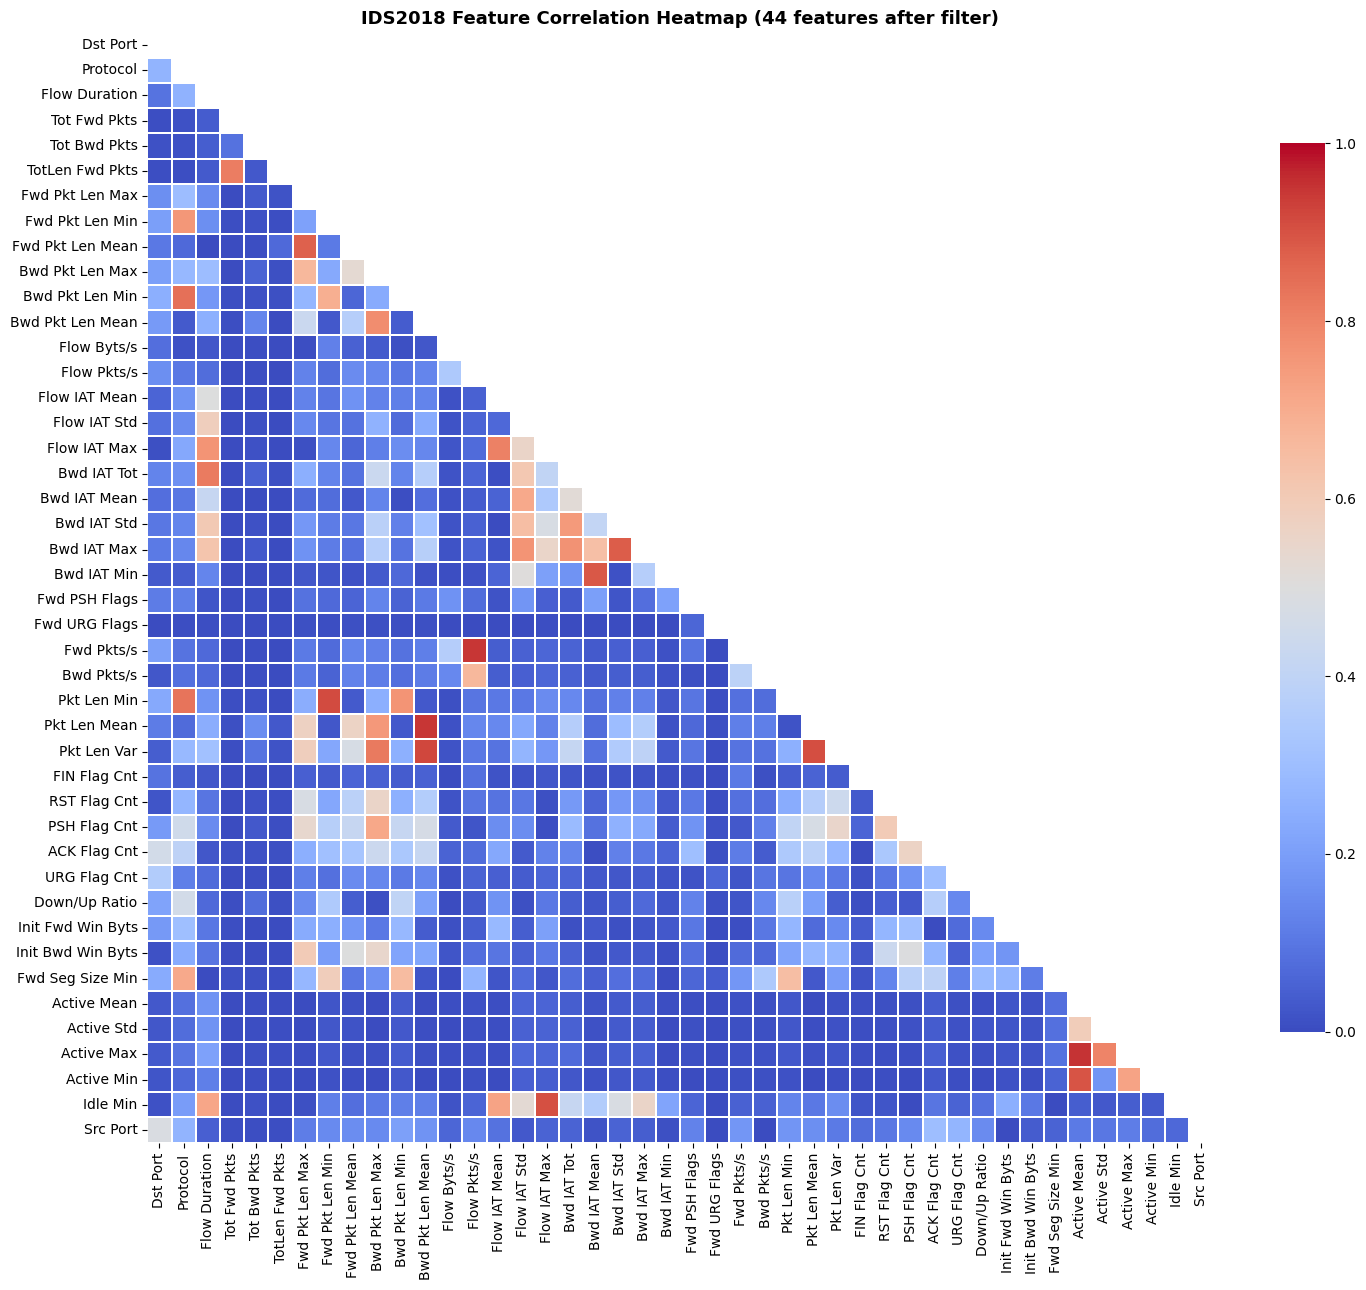

Max remaining correlation: 0.9509
Saved: ids2018_corr_heatmap.png


In [8]:
# Use a 50k sample from test set (already scaled) for speed
rng = np.random.default_rng(42)
idx = rng.choice(len(X_test), min(50_000, len(X_test)), replace=False)
sample_df = pd.DataFrame(X_test[idx], columns=feature_cols)

corr = sample_df.corr().abs()
mask = np.triu(np.ones_like(corr, dtype=bool))

fig, ax = plt.subplots(figsize=(15, 13))
sns.heatmap(corr, mask=mask, ax=ax, cmap='coolwarm', vmin=0, vmax=1,
            linewidths=0.2, cbar_kws={'shrink': 0.8})
ax.set_title(f'IDS2018 Feature Correlation Heatmap ({len(feature_cols)} features after filter)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(PLOTS_DIR / 'ids2018_corr_heatmap.png', dpi=120)
plt.show()
print(f'Max remaining correlation: {corr.where(~mask).max().max():.4f}')
print('Saved: ids2018_corr_heatmap.png')

## Step 7 — Non-IID Partition Heatmap (50 clients)

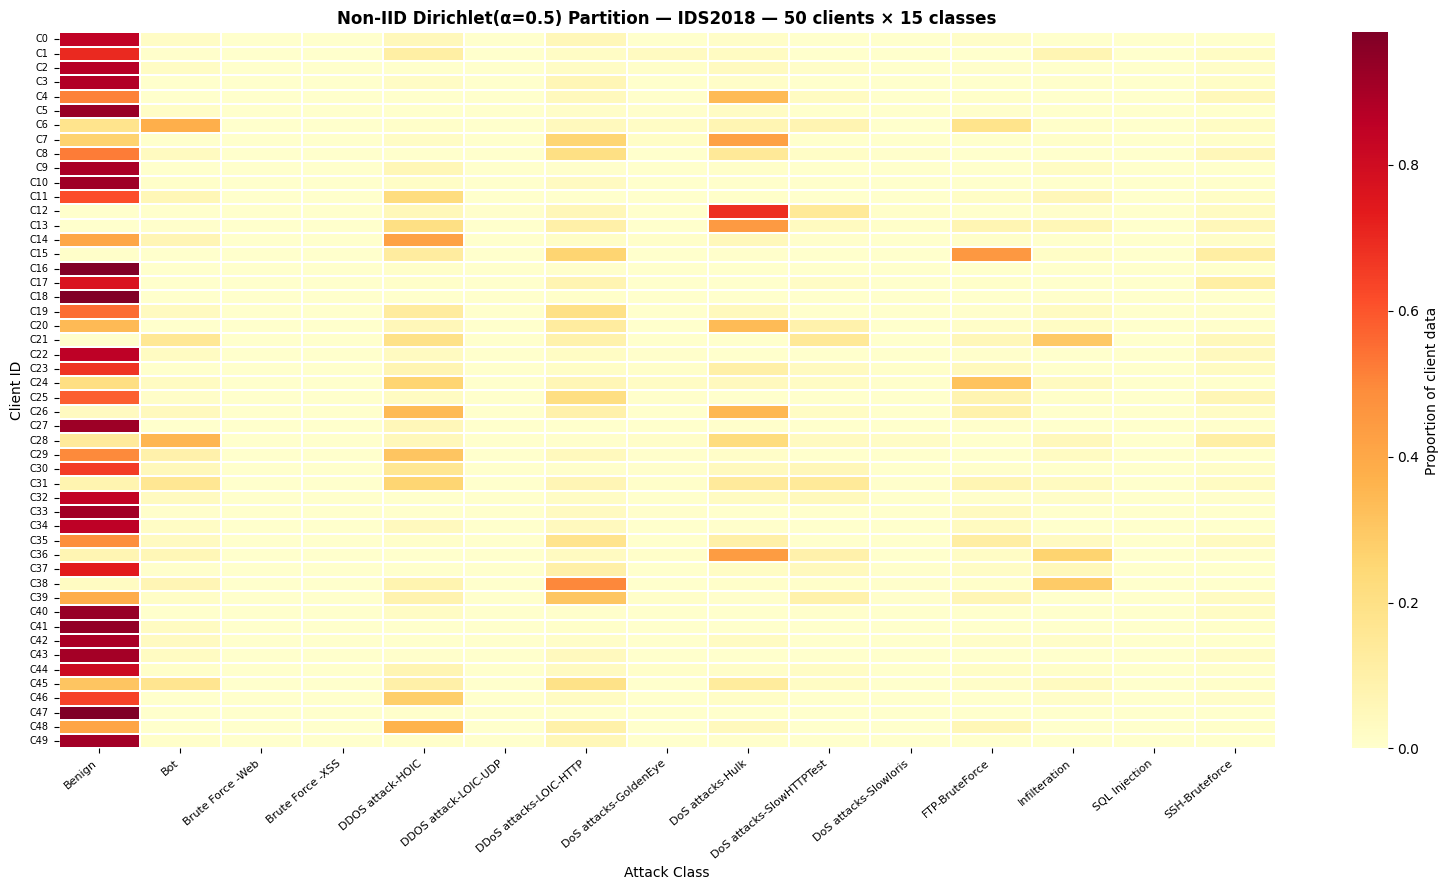

Saved: ids2018_noniid_partition.png

Rows per client (min/max): 7604 / 1609030


In [9]:
num_classes = len(le.classes_)
dist_matrix = np.zeros((num_clients, num_classes))

for cid in range(num_clients):
    shard = np.load(DATA_DIR / f'client_{cid:04d}.npz')
    y_c = shard['y_train']
    for cls in range(num_classes):
        dist_matrix[cid, cls] = (y_c == cls).sum()

# Normalise per row so colour shows proportion, not absolute count
row_sums = dist_matrix.sum(axis=1, keepdims=True)
dist_norm = dist_matrix / (row_sums + 1e-9)

fig, ax = plt.subplots(figsize=(16, 9))
sns.heatmap(dist_norm, ax=ax, cmap='YlOrRd',
            xticklabels=le.classes_, yticklabels=[f'C{i}' for i in range(num_clients)],
            linewidths=0.1, cbar_kws={'label': 'Proportion of client data'})
ax.set_title('Non-IID Dirichlet(α=0.5) Partition — IDS2018 — 50 clients × 15 classes',
             fontsize=12, fontweight='bold')
ax.set_xlabel('Attack Class')
ax.set_ylabel('Client ID')
plt.xticks(rotation=40, ha='right', fontsize=8)
plt.yticks(fontsize=7)
plt.tight_layout()
plt.savefig(PLOTS_DIR / 'ids2018_noniid_partition.png', dpi=150)
plt.show()
print('Saved: ids2018_noniid_partition.png')
print(f'\nRows per client (min/max): {dist_matrix.sum(axis=1).min():.0f} / {dist_matrix.sum(axis=1).max():.0f}')

## Summary — Confirmed Config Values

In [10]:
print('=' * 55)
print('  config.yaml values (already applied)')
print('=' * 55)
print(f'  model:')
print(f'    input_dim   : {len(feature_cols)}')
print(f'    num_classes : {len(le.classes_)}')
print(f'  attack:')
print(f'    source_class: {hoic_idx}  (DDOS attack-HOIC)')
print(f'    target_class: {benign_idx}  (Benign)')
print(f'  data:')
print(f'    num_clients : {num_clients}')
print(f'    dirichlet_alpha: 0.5  (Non-IID)')
print('=' * 55)
print()
print('Plots saved to:', PLOTS_DIR)

  config.yaml values (already applied)
  model:
    input_dim   : 44
    num_classes : 15
  attack:
    source_class: 4  (DDOS attack-HOIC)
    target_class: 0  (Benign)
  data:
    num_clients : 50
    dirichlet_alpha: 0.5  (Non-IID)

Plots saved to: C:\Users\rauna\Videos\FL IDS\artifacts\plots
